Importing modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lmfit as lm
import mathematical_functions as fn
import other_functions as oth
import os
import shutil
from datetime import datetime
from multiprocessing import Pool

Definitions of constants and functions

In [2]:
def FID_intensity(tau,parameters):

    first_comp = fn.sinc(parameters['first_b']*tau)*fn.T2_decay(tau, T2=parameters['first_T2'], A=parameters['first_A'], beta=parameters['first_beta'])

    second_comp = fn.T2_decay(tau, T2=parameters['second_T2'], A=parameters['second_A'], beta=parameters['second_beta'])

    third_comp = fn.T2_decay(tau, T2=parameters['third_T2'], A=parameters['third_A'], beta=parameters['third_beta'])

    intensity = first_comp + second_comp + third_comp
    return intensity

def derived_parameters(FID_params):
        FID_params.add('total_A', expr='first_A + second_A + third_A')
        FID_params.add('first_frac', expr='first_A/total_A')
        FID_params.add('second_frac', expr='second_A /total_A')
        FID_params.add('third_frac', expr='third_A /total_A')
        FID_params.add('first_a', expr='(2**0.5)/first_T2',min=0)
        FID_params.add('first_M2', expr='(first_a**2)+(first_b**2)/3',min=0)
        
        return FID_params

In [3]:
a=datetime.now()
print(a)

2026-04-25 01:46:48.187519


##############################################
#Variable Declarations
##############################################

In [4]:
exp_info = oth.read_exp_parameters()

data_cutoff=exp_info['data_cutoff'] #Cutoff for fitting limit


connectivity=['first','second','third'] #Number of components

Import the data

In [5]:
start=5
end=255
steps=1
FID_list=np.arange(start,end+1,steps)

exp_time_full=np.loadtxt("exp_time.txt")

exp_time=np.array([exp_time_full[i] for i in FID_list])

omit_points=np.arange(10)+1
print(omit_points)

[ 1  2  3  4  5  6  7  8  9 10]


In [6]:
df_dict,file = oth.high_field_FID_kinetics_rawdata(fidlist=FID_list,omit=omit_points)

df_main = df_dict.copy() #Backup of original table

C:\Users\bidit\Documents\All_Data\PhD_main_work\Analysis\crystallization\31


###############################################
#Define ranges for parameters
###############################################

In [7]:
ranges = {
    'first_T2': (0, 0.2), 'first_A': (0.0001, 1e3), 'first_beta': (1, 2), 'first_b': (0, 1000),
    'second_T2': (0.02, 0.200), 'second_A': (0.0001, 1e3), 'second_beta': (0.8, 2),
    'third_T2': (0.1, 2.00), 'third_A': (0.0001, 1e3), 'third_beta': (0.8, 2),
}

###############################################
#Initialize parameters
###############################################

In [8]:
FID_params = lm.Parameters()


# Add parameters to FID_params
for param, (min_val, max_val) in ranges.items():
    initial_value = (min_val + max_val) / 2  # Default initial value is the midpoint of the range
    FID_params.add(param, value=initial_value, vary=True, min=min_val, max=max_val)

# Randomize the parameters and get the updated parameters
FID_params = oth.randomize_parameters(FID_params, ranges)

Add derived parameters

In [9]:
FID_params =derived_parameters(FID_params)

Limit or fix parameters

In [10]:
FID_params['first_b'].set(value=0,vary=False)
FID_params['first_beta'].set(value=2,vary=True)

FID_params['second_A'].set(value=0,vary=False)
FID_params['second_T2'].set(value=1,vary=False)
FID_params['second_beta'].set(value=1,vary=False)

FID_params['third_beta'].set(value=1,vary=False)

# Define the difference of T2 and Dres values as parameters
FID_params.add('diff_T2_1',value=0.1,min=0,max=1)
FID_params['first_T2'].set(expr='second_T2 * diff_T2_1')


FID_params.add('diff_T2_2',value=0.1,min=0,max=1)
FID_params['second_T2'].set(expr='third_T2 * diff_T2_2')

##############################################
Do a global fit of the first point
##############################################

In [11]:
FID_model=FID_intensity

tau=df_dict[FID_list[0]]['Time']
FID=df_dict[FID_list[0]]['I_real']

FID_fit=lm.Minimizer(oth.fit_single,FID_params,fcn_args=(FID_model,tau,FID))

check_initial=False

if check_initial==True:
    FID_fitted_initial= FID_fit.minimize(method='basinhopping',params=FID_params)
else:
    FID_params= oth.load_object('last_fit_result_initial.pckl')
    FID_fitted_initial= FID_fit.minimize(method='leastsq',params=FID_params)


print(FID_fitted_initial.params.pretty_print())
result_initial=FID_fitted_initial.params.valuesdict()
fitted_initial=FID_model(tau,result_initial)
oth.write_object(FID_fitted_initial.params,'last_fit_result_initial.pckl')

Name            Value      Min      Max   Stderr     Vary     Expr Brute_Step
diff_T2_1      0.2274        0        1    51.59     True     None     None
diff_T2_2      0.1092        0        1    24.77     True     None     None
first_A         322.4   0.0001     1000   0.6267     True     None     None
first_M2         1194        0      inf 8.127e+05    False (first_a**2)+(first_b**2)/3     None
first_T2      0.04093        0      0.2 8.175e-05    False second_T2 * diff_T2_1     None
first_a         34.55        0      inf 1.176e+04    False (2**0.5)/first_T2     None
first_b             0        0     1000        0    False     None     None
first_beta       1.88        1        2  0.01461     True     None     None
first_frac     0.3398     -inf      inf 0.0005563    False first_A/total_A     None
second_A       0.0001   0.0001     1000        0    False     None     None
second_T2        0.18     0.02      0.2    40.84    False third_T2 * diff_T2_2     None
second_beta         1 

Fit other points by using the best fit of last as initial parameter1

In [12]:
fitted_dict={}
temp_params=FID_fitted_initial.params
for i in FID_list:
    tau=df_dict[i]['Time']
    FID=df_dict[i]['I_real']

    
    FID_fit=lm.Minimizer(oth.fit_single,temp_params,fcn_args=(FID_model,tau,FID))
    temp_fit= FID_fit.minimize(method='leastsq',params=temp_params)

    temp_params=temp_fit.params
    fitted_dict[i]=temp_fit

In [13]:
fitted_params_dict= {key:value.params for key,value in fitted_dict.items()}
oth.write_object(fitted_params_dict,'last_fit_result.pckl')

Plot the most relevant parameters

In [14]:
def plot_params_and_chisq(fitted_dict, *, sort_keys=True, ncols=4, figsize=None, sharex=True,hide_err=True,par_names=False):
        
    keys = sorted(fitted_dict) if sort_keys else list(fitted_dict.keys())
    first_res = fitted_dict[keys[0]]
    first_params = first_res.params.valuesdict()
    if not(par_names):
        par_names = list(first_params.keys())

    x = np.array(keys, dtype=float)
    n = len(keys)

    # extract values / errors / chisq
    vals = {p: np.empty(n) for p in par_names}
    errs = {p: np.empty(n) for p in par_names}
    chisq = np.empty(n)

    for i, k in enumerate(keys):
        res = fitted_dict[k]
        chisq[i] = res.chisqr
        for p in par_names:
            prm = res.params[p]
            vals[p][i] = prm.value
            errs[p][i] = np.nan if prm.stderr is None else min(prm.stderr,prm.value)

    n_plots = len(par_names) + 1
    nrows = int(np.ceil(n_plots / ncols))
    if figsize is None:
        figsize = (10, 2.8 * nrows)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharex=sharex)
    axes = np.atleast_1d(axes).ravel()

    # parameters
    for j, p in enumerate(par_names):
        ax = axes[j]
        if np.all(np.isnan(errs[p])) | hide_err:
            ax.plot(exp_time, vals[p], "-")
        else:
            ax.errorbar(exp_time, vals[p], yerr=errs[p], fmt="-", capsize=3)
        ax.set_ylabel(p)
        ax.grid(True, alpha=0.3)
    # chi-square
    ax = axes[len(par_names)]
    ax.plot(exp_time, chisq,  color="k")
    ax.set_ylabel("chisqr")
    ax.set_xlabel("Experiment Time / s")
    ax.grid(True, alpha=0.3)
    ax.set_xscale('log')
    # hide unused
    for ax in axes[n_plots:]:
        ax.axis("off")

    fig.tight_layout()
    return fig, axes

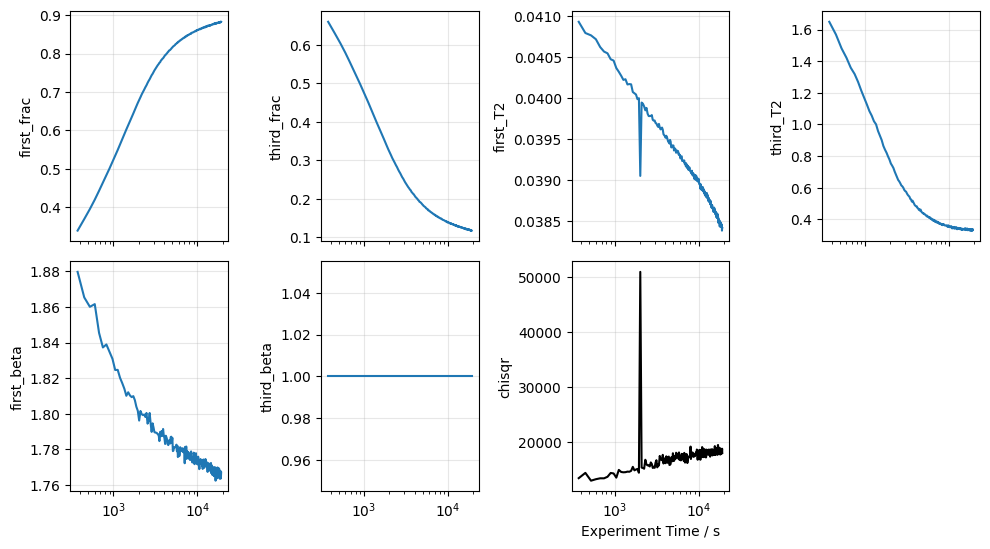

In [15]:
fig, axes = plot_params_and_chisq(fitted_dict,par_names=["first_frac","third_frac","first_T2","third_T2","first_beta","third_beta"])
plt.savefig(f'{file}_kinetics.pdf', format="pdf", bbox_inches="tight")
plt.savefig(f'{file}_kinetics.png', format="png", bbox_inches="tight")
plt.show()

Plot all the fits to one graph

In [16]:
for i,fits in fitted_dict.items():
    tau=df_dict[i]['Time']
    FID=df_dict[i]['I_real']
    result_temp=fits.params.valuesdict()
    fitted_temp=FID_model(tau,result_temp)
    plt.plot(tau,fitted_temp)
    plt.ylim(0,None)
plt.savefig(f'{file}_fit.pdf', format="pdf", bbox_inches="tight")
plt.savefig(f'{file}_fit.png', format="png", bbox_inches="tight")
plt.close()

Create an animation of all the time series

In [17]:
from matplotlib.animation import FuncAnimation, PillowWriter

fig, ax = plt.subplots()

def update(frame):
    ax.clear()
    i, fits = frame

    tau = np.asarray(df_dict[i]["Time"])
    FID = np.asarray(df_dict[i]["I_real"])
    params = fits.params.valuesdict()

    fitted_temp = np.asarray(FID_model(tau, params))   # or: FID_model(tau, **params)

    ax.plot(tau, fitted_temp,color="k")
    ax.scatter(tau, FID)
    ax.set_ylim(0, None)
    ax.set_title(oth.second_to_hrminsec(exp_time_full[i]))

# one frame per item in fitted_dict
frames = list(fitted_dict.items())

anim = FuncAnimation(fig, update, frames=frames, blit=False)
anim.save(f"{file}_fid_kinetics_fit.gif", writer=PillowWriter(fps=5))
plt.close(fig)

# =============================================================================
# Determine individual fits and write to dataframe
# =============================================================================

In [18]:
df_result=pd.DataFrame()
df_params=pd.DataFrame()
for i,fits in fitted_dict.items():
    tau=df_dict[i]['Time']
    FID=df_dict[i]['I_real']
    
    result_temp=fits.params.valuesdict()
    
    fitted_temp=FID_model(tau,result_temp)
 
    
    
    components_FID = {}
    for x in connectivity:
        components_FID[f'{x}_'] = fn.T2_decay(tau, result_temp[f'{x}_T2'],result_temp[f'{x}_A'], result_temp[f'{x}_beta'])
    
    #Add sinc oscillations for rigid component
    components_FID['first_']=components_FID['first_'] * fn.sinc(tau*result_temp['first_b'])
    
    # Full FID Fit
    fitted_points_FID = {
        **components_FID,
        'Full_Fit_': FID_model(tau,result_temp)
    }

    #oth.plot_results_FID(tau, FID, fitted_points_FID, f'{file}_{i}')
    
    df_result_temp= oth.files_report_FID(df_dict[i],file,fitted_points_FID,fits,write=False)
    df_result_temp["exp_time"]=exp_time_full[i]
    
    df_params_temp = oth.minimizer_result_to_dataframe(fits, file)
    df_params_temp["exp_time"]=exp_time_full[i]

    df_result=pd.concat([df_result,df_result_temp.round(6)])
    df_params=pd.concat([df_params,df_params_temp])

    
    plt.plot(tau,components_FID['first_'])
    #plt.ylim(0,None)
plt.savefig(f'{file}_crystal.pdf', format="pdf", bbox_inches="tight")
plt.savefig(f'{file}_crystal.png', format="png", bbox_inches="tight")
plt.close()
df_result.to_csv(file+'_fit_value.csv',index=False)
df_params.to_csv(file+'_fit_report.csv',index=False)

C:\Users\bidit\AppData\Local\Temp\ipykernel_40564\921340791.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_params=pd.concat([df_params,df_params_temp])
C:\Users\bidit\AppData\Local\Temp\ipykernel_40564\921340791.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_params=pd.concat([df_params,df_params_temp])
C:\Users\bidit\AppData\Local\Temp\ipykernel_40564\921340791.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future 

In [19]:
b=datetime.now()
print(b)
print(f'Execution time is {b-a}')

2026-04-25 01:48:00.768049
Execution time is 0:01:12.580530
